## Neural Network

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
df = pd.read_csv('engineered_features_scaled.csv')

In [21]:
X = df.drop(columns='revenue').values.astype(np.float32)
y = df['revenue'].values.astype(np.float32).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [23]:
# a 15 % validation split is carved from training data
def make_tensors(*arrays):
    return [torch.tensor(np.array(a), dtype = torch.float32) for a in arrays]

X_tr_t, y_tr_t = make_tensors(X_train, y_train)
X_te_t, y_te_t = make_tensors(X_test,  y_test)

full_train = TensorDataset(X_tr_t, y_tr_t)
val_size = int(len(full_train) * 0.15)
train_size = len(full_train) - val_size

train_ds, val_ds = random_split( full_train, [train_size, val_size],
    generator = torch.Generator().manual_seed(SEED))

BATCH_SIZE =  128 # 256 #512
train_loader = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_ds, batch_size = BATCH_SIZE)
test_loader = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size = BATCH_SIZE)

In [24]:
# builds the model
def build_regression_mlp(input_dim, hidden_layers = (128, 64, 32), dropout_rate = 0.3):
    layers = []
    in_dim = input_dim
    for units in hidden_layers:
        layers += [
            nn.Linear(in_dim, units),
            nn.ReLU(),
            nn.BatchNorm1d(units),
            nn.Dropout(dropout_rate),
        ]
        in_dim = units
    # linear output = regression
    layers.append(nn.Linear(in_dim, 1))
    return nn.Sequential(*layers)

# the features
INPUT_DIM = X_train.shape[1]
model = build_regression_mlp(INPUT_DIM)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Sequential(
  (0): Linear(in_features=38, out_features=128, bias=True)
  (1): ReLU()
  (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): ReLU()
  (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): Dropout(p=0.3, inplace=False)
  (8): Linear(in_features=64, out_features=32, bias=True)
  (9): ReLU()
  (10): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): Dropout(p=0.3, inplace=False)
  (12): Linear(in_features=32, out_features=1, bias=True)
)

Total parameters: 15,809


In [25]:
# sets up the training for the model
# learning rate, learning_rates = [0.01, 0.1, 0.5]
lr  = 0.01 #1e-3
EPOCHS = 75
# early stopping patience
PATIENCE = 5
# ReduceLROnPlateau patience
LR_PATIENCE = 3
# halfs LR on plateau
LR_FACTOR = 0.5
MIN_LR = 1e-6

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = lr)

# PyTorch callbacks
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = 'min',factor = LR_FACTOR,
    patience = LR_PATIENCE, min_lr = MIN_LR,)

In [26]:
# loops through to train the model,stops early if the best weights are found
train_losses, val_losses = [], []
best_val_loss = float('inf')
best_state = None
patience_cnt = 0

for epoch in range(1, EPOCHS + 1):
    #  trains the model
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_mse = np.mean(batch_losses)

    # validate the model
    model.eval()
    with torch.no_grad():
        v_losses = [criterion(model(Xv), yv).item() for Xv, yv in val_loader]
    val_mse = np.mean(v_losses)

    train_losses.append(train_mse)
    val_losses.append(val_mse)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:3d}/{EPOCHS}  "
          f"train_mse={train_mse:.4f}  val_mse={val_mse:.4f}  lr={current_lr:.2e}")

    # ReduceLROnPlateau step
    scheduler.step(val_mse)

    # stops and restores the best weights
    if val_mse < best_val_loss:
        best_val_loss = val_mse
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} (best val_mse={best_val_loss:.4f})")
            break

# restores the  best weights
model.load_state_dict(best_state)

Epoch   1/75  train_mse=156.6540  val_mse=13.7952  lr=1.00e-02
Epoch   2/75  train_mse=12.8251  val_mse=5.1253  lr=1.00e-02
Epoch   3/75  train_mse=9.5131  val_mse=4.7277  lr=1.00e-02
Epoch   4/75  train_mse=8.3646  val_mse=4.8020  lr=1.00e-02
Epoch   5/75  train_mse=8.2810  val_mse=4.4767  lr=1.00e-02
Epoch   6/75  train_mse=7.9230  val_mse=4.4042  lr=1.00e-02
Epoch   7/75  train_mse=7.8947  val_mse=4.5014  lr=1.00e-02
Epoch   8/75  train_mse=7.7670  val_mse=4.3633  lr=1.00e-02
Epoch   9/75  train_mse=7.6874  val_mse=4.4080  lr=1.00e-02
Epoch  10/75  train_mse=7.6737  val_mse=4.2993  lr=1.00e-02
Epoch  11/75  train_mse=7.4324  val_mse=4.3211  lr=1.00e-02
Epoch  12/75  train_mse=7.5281  val_mse=4.2417  lr=1.00e-02
Epoch  13/75  train_mse=7.3044  val_mse=4.1401  lr=1.00e-02
Epoch  14/75  train_mse=7.4680  val_mse=4.1805  lr=1.00e-02
Epoch  15/75  train_mse=7.2952  val_mse=4.2237  lr=1.00e-02
Epoch  16/75  train_mse=7.1763  val_mse=4.0933  lr=1.00e-02
Epoch  17/75  train_mse=7.0747  val_

<All keys matched successfully>

In [27]:
# evaluate the model
model.eval()
with torch.no_grad():
    y_pred_t = model(X_te_t).numpy().flatten()
y_true = y_te_t.numpy().flatten()

rmse_nn = np.sqrt(mean_squared_error(y_true, y_pred_t))
r2_nn = r2_score(y_true, y_pred_t)
mse_nn = mean_squared_error(y_true, y_pred_t)

print("Neural Network RMSE: ", rmse_nn)
print("Neural NetworkR2: ", r2_nn)
print("Neural Network MSE: ", mse_nn)

Neural Network RMSE:  2.0103939101227506
Neural NetworkR2:  0.4716668725013733
Neural Network MSE:  4.041683673858643


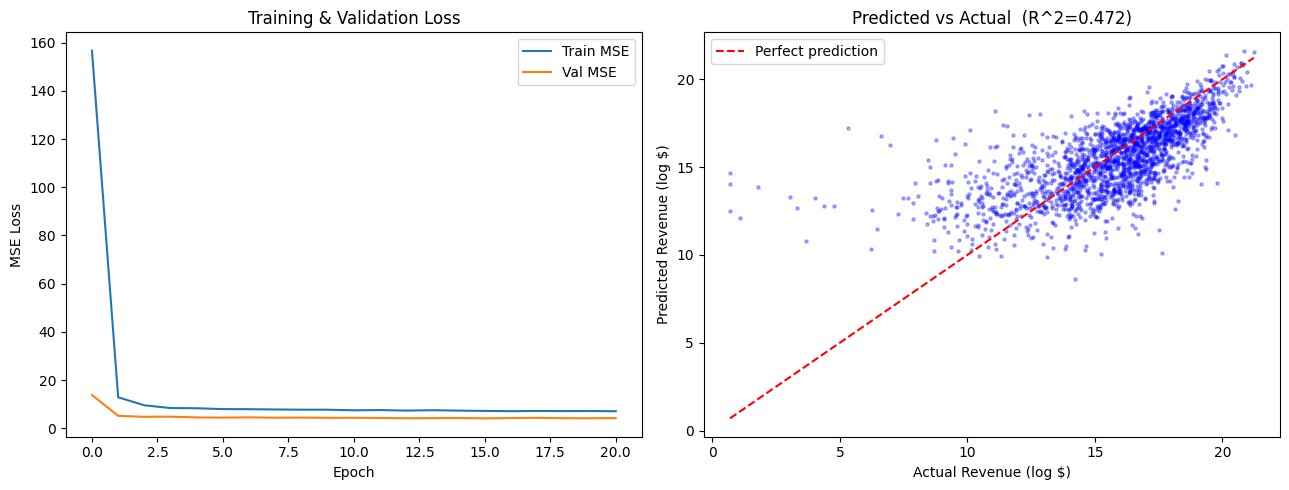

In [28]:
# creates the plots
fig, axes = plt.subplots(1, 2, figsize = (13, 5))

# Loss curves
axes[0].plot(train_losses, label = "Train MSE")
axes[0].plot(val_losses,   label = "Val MSE")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Training & Validation Loss")
axes[0].legend()

# Predicted vs Actual
axes[1].scatter(y_true, y_pred_t, alpha = 0.3, s = 5, color = "blue")
axes[1].set_xlabel("Actual Revenue (log $)")
axes[1].set_ylabel("Predicted Revenue (log $)")
axes[1].set_title(f"Predicted vs Actual  (R^2={r2_nn:.3f})")
lim = [y_true.min(), y_true.max()]
axes[1].plot(lim, lim, 'r--', label = "Perfect prediction")
axes[1].legend()

plt.tight_layout()
plt.show()